In [ ]:
'''# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session'''

### Embedding Visualization using t-SNE



In this notebook, we perform qualitative analysis of the learned node representations using t-SNE visualization.

A trained model from a representative seed is loaded, and embeddings are extracted from the hidden layer prior to the final classification layer. These high-dimensional embeddings are projected into a 2D space using t-SNE to reveal the structure of the learned feature space.

Nodes are colored according to their ground-truth labels, and misclassified nodes are highlighted to better understand model errors.



In [1]:
! pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.6 MB/s eta 0:00:00a 0:00:01


In [2]:
import torch
import torch_geometric

print(torch.__version__)
print(torch_geometric.__version__)


2.10.0+cpu
2.7.0


In [3]:
from torch_geometric.datasets import Amazon
dataset=Amazon(root='/kaggle/working/Amazon',name='Computers')
data=dataset[0]
print(data)



Processing...


Data(x=[13752, 767], edge_index=[2, 491722], y=[13752])


Done!


In [9]:
best_config= {'hidden_dim': 8, 'lr': 0.001, 'heads': 8, 'dropout': 0.5}


### GAT(2 layers) 

In [13]:
import torch.nn.functional as F
from torch_geometric.nn import GATConv
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6):
        super().__init__()
        
        self.dropout = dropout
        
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout)

    def forward(self, x, edge_index,return_embeddings=False):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        if(return_embeddings):
            return x
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

In [14]:
#GAT(2 Layer)

GAT_model_2 = GAT( 
    in_channels=data.num_features,
    hidden_channels=best_config["hidden_dim"],
    out_channels=dataset.num_classes,
    heads=best_config["heads"],
    dropout=best_config["dropout"]
).to(device)

GAT_model_2.load_state_dict(torch.load("/kaggle/input/datasets/mrxn251/gat-models/best_modelGAT_3.pt", map_location=device))
GAT_model_2.eval()
for name, param in GAT_model_2.named_parameters():
    print(name, param.shape)

conv1.att_src torch.Size([1, 8, 8])
conv1.att_dst torch.Size([1, 8, 8])
conv1.bias torch.Size([64])
conv1.lin.weight torch.Size([64, 767])
conv2.att_src torch.Size([1, 1, 10])
conv2.att_dst torch.Size([1, 1, 10])
conv2.bias torch.Size([10])
conv2.lin.weight torch.Size([10, 64])


In [15]:
with torch.no_grad():
    embeddings = GAT_model_2(data.x, data.edge_index, return_embeddings=True)

In [16]:
from sklearn.manifold import TSNE
emb_2d = TSNE(n_components=2).fit_transform(embeddings.cpu().numpy())

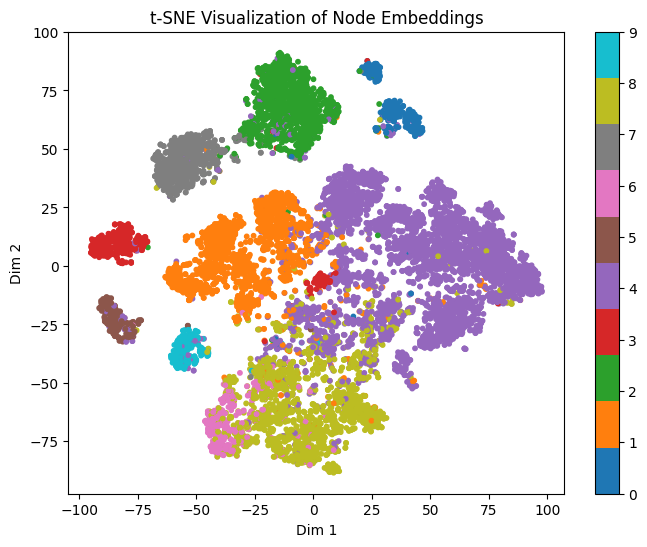

In [17]:
import matplotlib.pyplot as plt

labels = data.y.cpu().numpy()

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=labels,
    cmap='tab10',
    s=10
)

plt.colorbar(scatter)
plt.title("t-SNE Visualization of Node Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.show()

In [18]:
#Highlighting misclassified nodes
with torch.no_grad():
    logits = GAT_model_2(data.x, data.edge_index,return_embeddings=False)
    preds = logits.argmax(dim=1).cpu().numpy()

labels = data.y.cpu().numpy()
correct = (preds == labels)

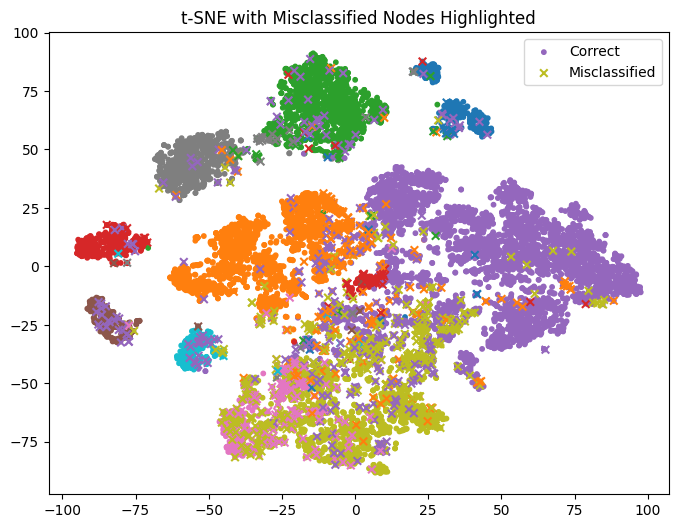

In [19]:
plt.figure(figsize=(8,6))

# Correct predictions → circles
plt.scatter(
    emb_2d[correct, 0],
    emb_2d[correct, 1],
    c=labels[correct],
    cmap='tab10',
    s=10,
    marker='o',
    label='Correct'
)

# Wrong predictions → crosses
plt.scatter(
    emb_2d[~correct, 0],
    emb_2d[~correct, 1],
    c=labels[~correct],
    cmap='tab10',
    s=30,
    marker='x',
    label='Misclassified'
)

plt.legend()
plt.title("t-SNE with Misclassified Nodes Highlighted")
plt.show()

### GAT(4 layers)

In [20]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6):
        super().__init__()
        
        self.dropout = dropout

        # Layer 1
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)

        # Layer 2
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout)

        # Layer 3
        self.conv3 = GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout)

        # Layer 4 (output layer)
        self.conv4 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout)

    def forward(self, x, edge_index,return_embedding=False):
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = F.elu(x)

        if(return_embedding):
            return x
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv4(x, edge_index)

        return x

In [21]:
GAT_model_4 = GAT( 
    in_channels=data.num_features,
    hidden_channels=best_config["hidden_dim"],
    out_channels=dataset.num_classes,
    heads=best_config["heads"],
    dropout=best_config["dropout"]
).to(device)

GAT_model_4.load_state_dict(torch.load("/kaggle/input/datasets/mrxn251/gat-models/best_modelGAT_0(4 layers).pt", map_location=device))
GAT_model_4.eval()
for name, param in GAT_model_4.named_parameters():
    print(name, param.shape)

conv1.att_src torch.Size([1, 8, 8])
conv1.att_dst torch.Size([1, 8, 8])
conv1.bias torch.Size([64])
conv1.lin.weight torch.Size([64, 767])
conv2.att_src torch.Size([1, 8, 8])
conv2.att_dst torch.Size([1, 8, 8])
conv2.bias torch.Size([64])
conv2.lin.weight torch.Size([64, 64])
conv3.att_src torch.Size([1, 8, 8])
conv3.att_dst torch.Size([1, 8, 8])
conv3.bias torch.Size([64])
conv3.lin.weight torch.Size([64, 64])
conv4.att_src torch.Size([1, 1, 10])
conv4.att_dst torch.Size([1, 1, 10])
conv4.bias torch.Size([10])
conv4.lin.weight torch.Size([10, 64])


In [26]:
with torch.no_grad():
    embeddings = GAT_model_4(data.x, data.edge_index, return_embedding=True)

In [27]:
from sklearn.manifold import TSNE
emb_2d = TSNE(n_components=2).fit_transform(embeddings.cpu().numpy())

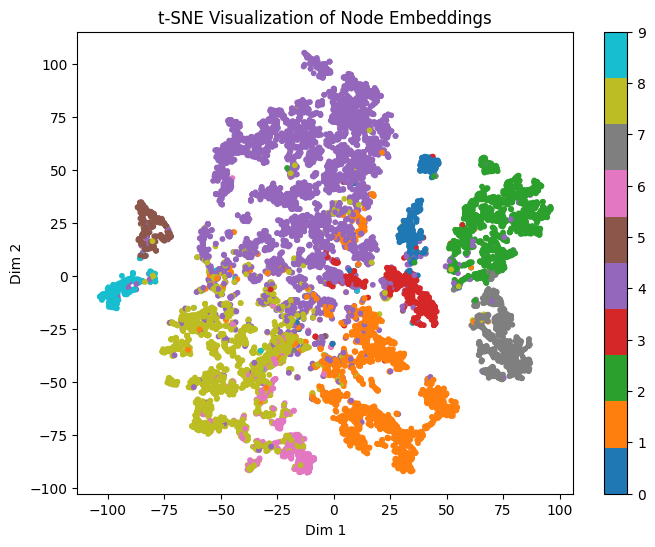

In [28]:
import matplotlib.pyplot as plt

labels = data.y.cpu().numpy()

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=labels,
    cmap='tab10',
    s=10
)

plt.colorbar(scatter)
plt.title("t-SNE Visualization of Node Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.show()

In [29]:
#Highlighting misclassified nodes
with torch.no_grad():
    logits = GAT_model_4(data.x, data.edge_index,return_embedding=False)
    preds = logits.argmax(dim=1).cpu().numpy()

labels = data.y.cpu().numpy()
correct = (preds == labels)

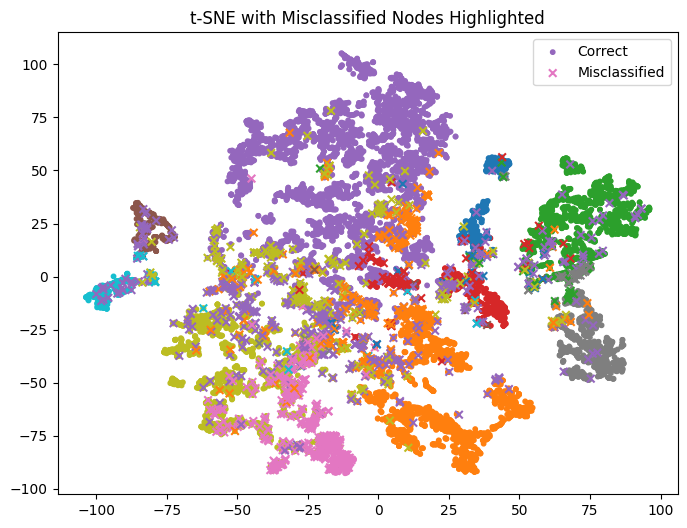

In [30]:
plt.figure(figsize=(8,6))

# Correct predictions → circles
plt.scatter(
    emb_2d[correct, 0],
    emb_2d[correct, 1],
    c=labels[correct],
    cmap='tab10',
    s=10,
    marker='o',
    label='Correct'
)

# Wrong predictions → crosses
plt.scatter(
    emb_2d[~correct, 0],
    emb_2d[~correct, 1],
    c=labels[~correct],
    cmap='tab10',
    s=30,
    marker='x',
    label='Misclassified'
)

plt.legend()
plt.title("t-SNE with Misclassified Nodes Highlighted")
plt.show()

### GAT(6 layers)

In [34]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6):
        super().__init__()
        
        self.dropout = dropout

        # Layer 1
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)

        # Hidden layers
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout)
        self.conv3 = GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout)
        self.conv4 = GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout)
        self.conv5 = GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout)

        # Output layer
        self.conv6 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout)

    def forward(self, x, edge_index,return_embedding=False):
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv4(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv5(x, edge_index)
        x = F.elu(x)

        if(return_embedding):
            return x
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv6(x, edge_index)

        return x

In [35]:
GAT_model_6 = GAT( 
    in_channels=data.num_features,
    hidden_channels=best_config["hidden_dim"],
    out_channels=dataset.num_classes,
    heads=best_config["heads"],
    dropout=best_config["dropout"]
).to(device)

GAT_model_6.load_state_dict(torch.load("/kaggle/input/datasets/mrxn251/gat-models/best_modelGAT_9(6 layers).pt", map_location=device))
GAT_model_6.eval()
for name, param in GAT_model_6.named_parameters():
    print(name, param.shape)

conv1.att_src torch.Size([1, 8, 8])
conv1.att_dst torch.Size([1, 8, 8])
conv1.bias torch.Size([64])
conv1.lin.weight torch.Size([64, 767])
conv2.att_src torch.Size([1, 8, 8])
conv2.att_dst torch.Size([1, 8, 8])
conv2.bias torch.Size([64])
conv2.lin.weight torch.Size([64, 64])
conv3.att_src torch.Size([1, 8, 8])
conv3.att_dst torch.Size([1, 8, 8])
conv3.bias torch.Size([64])
conv3.lin.weight torch.Size([64, 64])
conv4.att_src torch.Size([1, 8, 8])
conv4.att_dst torch.Size([1, 8, 8])
conv4.bias torch.Size([64])
conv4.lin.weight torch.Size([64, 64])
conv5.att_src torch.Size([1, 8, 8])
conv5.att_dst torch.Size([1, 8, 8])
conv5.bias torch.Size([64])
conv5.lin.weight torch.Size([64, 64])
conv6.att_src torch.Size([1, 1, 10])
conv6.att_dst torch.Size([1, 1, 10])
conv6.bias torch.Size([10])
conv6.lin.weight torch.Size([10, 64])


In [36]:
with torch.no_grad():
    embeddings = GAT_model_6(data.x, data.edge_index, return_embedding=True)

In [37]:
from sklearn.manifold import TSNE
emb_2d = TSNE(n_components=2).fit_transform(embeddings.cpu().numpy())

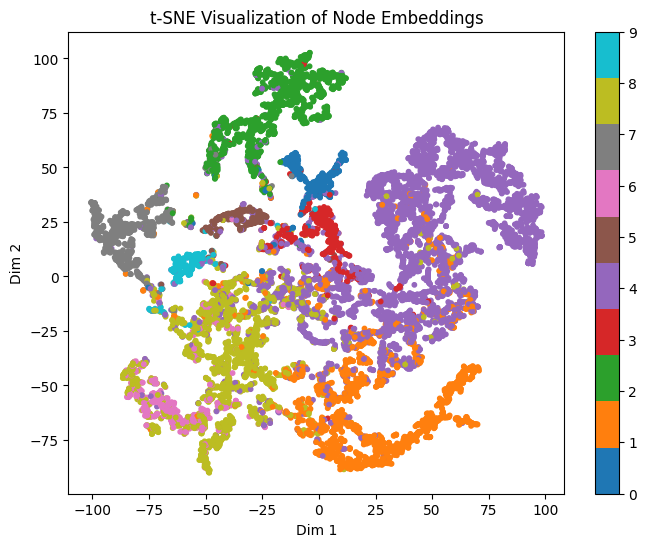

In [38]:
import matplotlib.pyplot as plt

labels = data.y.cpu().numpy()

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=labels,
    cmap='tab10',
    s=10
)

plt.colorbar(scatter)
plt.title("t-SNE Visualization of Node Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.show()

In [39]:
#Highlighting misclassified nodes
with torch.no_grad():
    logits = GAT_model_4(data.x, data.edge_index,return_embedding=False)
    preds = logits.argmax(dim=1).cpu().numpy()

labels = data.y.cpu().numpy()
correct = (preds == labels)

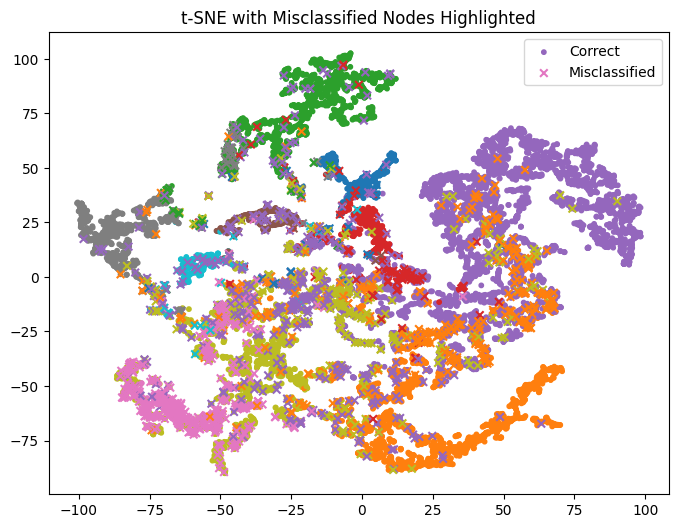

In [40]:
plt.figure(figsize=(8,6))

# Correct predictions → circles
plt.scatter(
    emb_2d[correct, 0],
    emb_2d[correct, 1],
    c=labels[correct],
    cmap='tab10',
    s=10,
    marker='o',
    label='Correct'
)

# Wrong predictions → crosses
plt.scatter(
    emb_2d[~correct, 0],
    emb_2d[~correct, 1],
    c=labels[~correct],
    cmap='tab10',
    s=30,
    marker='x',
    label='Misclassified'
)

plt.legend()
plt.title("t-SNE with Misclassified Nodes Highlighted")
plt.show()

### GAT(8 Layer)

In [41]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.6):
        super().__init__()
        
        self.dropout = dropout

        # Layer 1
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)

        # Hidden layers
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout)
        self.conv3 = GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout)
        self.conv4 = GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout)
        self.conv5 = GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout)
        self.conv6 = GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout)
        self.conv7 = GATConv(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout)

        # Output layer
        self.conv8 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout)

    def forward(self, x, edge_index,return_embedding=False):
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv3(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv4(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv5(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv6(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv7(x, edge_index)
        x = F.elu(x)
        if(return_embedding):
            return x
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv8(x, edge_index)

        return x

In [43]:
GAT_model_8 = GAT( 
    in_channels=data.num_features,
    hidden_channels=best_config["hidden_dim"],
    out_channels=dataset.num_classes,
    heads=best_config["heads"],
    dropout=best_config["dropout"]
).to(device)

GAT_model_8.load_state_dict(torch.load("/kaggle/input/datasets/mrxn251/gat-models/best_modelGAT_0(8 layers).pt", map_location=device))
GAT_model_8.eval()
for name, param in GAT_model_8.named_parameters():
    print(name, param.shape)

conv1.att_src torch.Size([1, 8, 8])
conv1.att_dst torch.Size([1, 8, 8])
conv1.bias torch.Size([64])
conv1.lin.weight torch.Size([64, 767])
conv2.att_src torch.Size([1, 8, 8])
conv2.att_dst torch.Size([1, 8, 8])
conv2.bias torch.Size([64])
conv2.lin.weight torch.Size([64, 64])
conv3.att_src torch.Size([1, 8, 8])
conv3.att_dst torch.Size([1, 8, 8])
conv3.bias torch.Size([64])
conv3.lin.weight torch.Size([64, 64])
conv4.att_src torch.Size([1, 8, 8])
conv4.att_dst torch.Size([1, 8, 8])
conv4.bias torch.Size([64])
conv4.lin.weight torch.Size([64, 64])
conv5.att_src torch.Size([1, 8, 8])
conv5.att_dst torch.Size([1, 8, 8])
conv5.bias torch.Size([64])
conv5.lin.weight torch.Size([64, 64])
conv6.att_src torch.Size([1, 8, 8])
conv6.att_dst torch.Size([1, 8, 8])
conv6.bias torch.Size([64])
conv6.lin.weight torch.Size([64, 64])
conv7.att_src torch.Size([1, 8, 8])
conv7.att_dst torch.Size([1, 8, 8])
conv7.bias torch.Size([64])
conv7.lin.weight torch.Size([64, 64])
conv8.att_src torch.Size([1, 1, 1

In [44]:
with torch.no_grad():
    embeddings = GAT_model_8(data.x, data.edge_index, return_embedding=True)

In [45]:
from sklearn.manifold import TSNE
emb_2d = TSNE(n_components=2).fit_transform(embeddings.cpu().numpy())

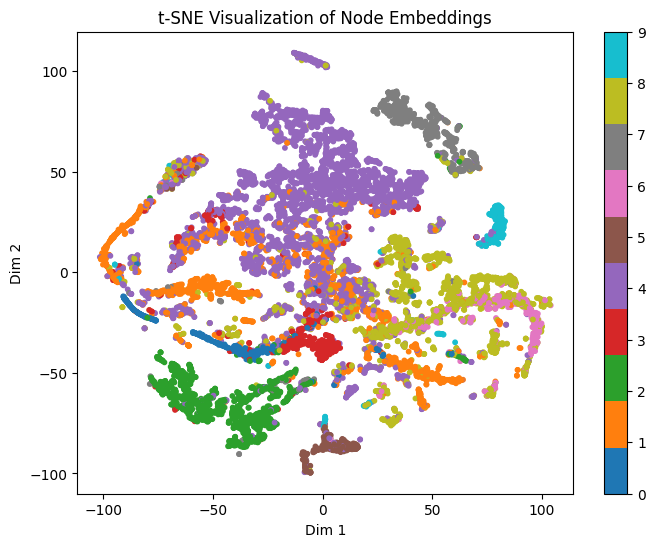

In [46]:
import matplotlib.pyplot as plt

labels = data.y.cpu().numpy()

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=labels,
    cmap='tab10',
    s=10
)

plt.colorbar(scatter)
plt.title("t-SNE Visualization of Node Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.show()

In [47]:
#Highlighting misclassified nodes
with torch.no_grad():
    logits = GAT_model_4(data.x, data.edge_index,return_embedding=False)
    preds = logits.argmax(dim=1).cpu().numpy()

labels = data.y.cpu().numpy()
correct = (preds == labels)

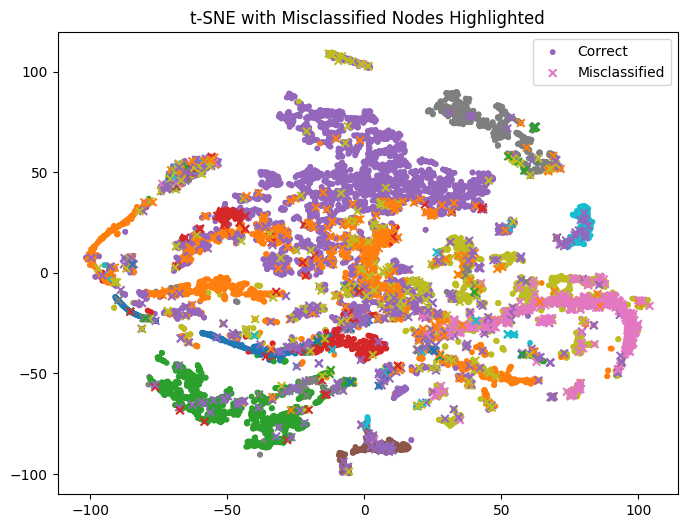

In [48]:
plt.figure(figsize=(8,6))

# Correct predictions → circles
plt.scatter(
    emb_2d[correct, 0],
    emb_2d[correct, 1],
    c=labels[correct],
    cmap='tab10',
    s=10,
    marker='o',
    label='Correct'
)

# Wrong predictions → crosses
plt.scatter(
    emb_2d[~correct, 0],
    emb_2d[~correct, 1],
    c=labels[~correct],
    cmap='tab10',
    s=30,
    marker='x',
    label='Misclassified'
)

plt.legend()
plt.title("t-SNE with Misclassified Nodes Highlighted")
plt.show()

### SGC

In [54]:
from torch_geometric.nn import SGConv
class SGC(torch.nn.Module):
    def __init__(self, in_channels, out_channels, K=2):
        super().__init__()
        self.conv = SGConv(in_channels, out_channels, K=K, cached=True)

    def forward(self, x, edge_index, return_embedding=False):
        out = self.conv(x, edge_index)

        if return_embedding:
            return out  # logits = embeddings

        return out

In [55]:
SGC_model = SGC(
    in_channels=data.num_features,
    out_channels=dataset.num_classes,
    K=2
).to(device)

SGC_model.load_state_dict(
    torch.load("/kaggle/input/datasets/mrxn251/gnn-model-others/best_modelSGC_5.pt",
               map_location=device)
)

SGC_model.eval()

SGC(
  (conv): SGConv(767, 10, K=2)
)

In [56]:
with torch.no_grad():
    embeddings = SGC_model(data.x, data.edge_index, return_embedding=True)

In [57]:
from sklearn.manifold import TSNE
emb_2d = TSNE(n_components=2).fit_transform(embeddings.cpu().numpy())

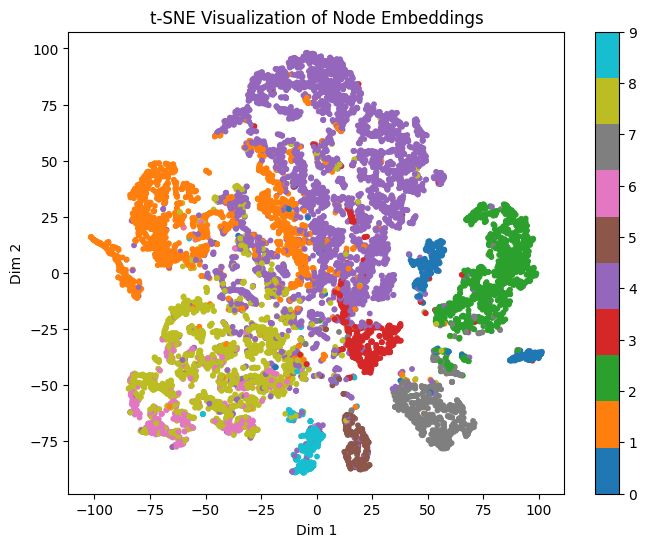

In [58]:
import matplotlib.pyplot as plt

labels = data.y.cpu().numpy()

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=labels,
    cmap='tab10',
    s=10
)

plt.colorbar(scatter)
plt.title("t-SNE Visualization of Node Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.show()

In [59]:
#Highlighting misclassified nodes
with torch.no_grad():
    logits = GAT_model_4(data.x, data.edge_index,return_embedding=False)
    preds = logits.argmax(dim=1).cpu().numpy()

labels = data.y.cpu().numpy()
correct = (preds == labels)

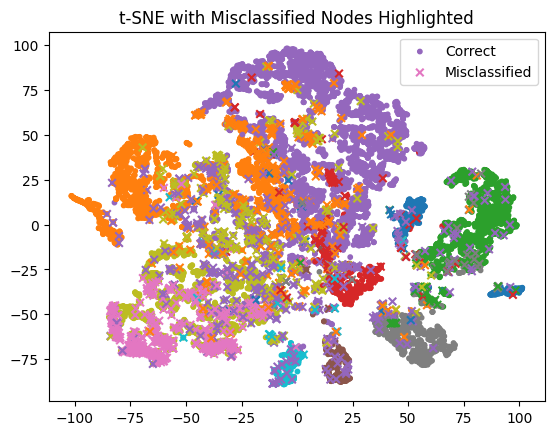

In [60]:

# Correct predictions → circles
plt.scatter(
    emb_2d[correct, 0],
    emb_2d[correct, 1],
    c=labels[correct],
    cmap='tab10',
    s=10,
    marker='o',
    label='Correct'
)

# Wrong predictions → crosses
plt.scatter(
    emb_2d[~correct, 0],
    emb_2d[~correct, 1],
    c=labels[~correct],
    cmap='tab10',
    s=30,
    marker='x',
    label='Misclassified'
)

plt.legend()
plt.title("t-SNE with Misclassified Nodes Highlighted")
plt.show()

### GCN 

In [61]:
from torch_geometric.nn import GCNConv
import torch.nn.functional as F
class GCN(torch.nn.Module):
    def __init__(self,in_channels,hidden_channels,out_channels):
        super().__init__()
        self.conv1=GCNConv(in_channels,hidden_channels)
        self.conv2=GCNConv(hidden_channels,out_channels)
    def forward(self,x,edge_index,return_embedding=False):
        x=self.conv1(x,edge_index)
        x=F.relu(x)
        if(return_embedding):
            return x
        x=self.conv2(x,edge_index)
        return x

In [63]:
GCN_model = GCN(
    in_channels=data.num_features,
    hidden_channels=32,
    out_channels=dataset.num_classes
).to(device)

GCN_model.load_state_dict(
    torch.load("/kaggle/input/datasets/mrxn251/gnn-model-others/best_modelGCN_6.pt",
               map_location=device)
)

GCN_model.eval()

GCN(
  (conv1): GCNConv(767, 32)
  (conv2): GCNConv(32, 10)
)

In [71]:
with torch.no_grad():
    embeddings = GCN_model(data.x, data.edge_index, return_embedding=True)

In [72]:
from sklearn.manifold import TSNE
emb_2d = TSNE(n_components=2).fit_transform(embeddings.cpu().numpy())

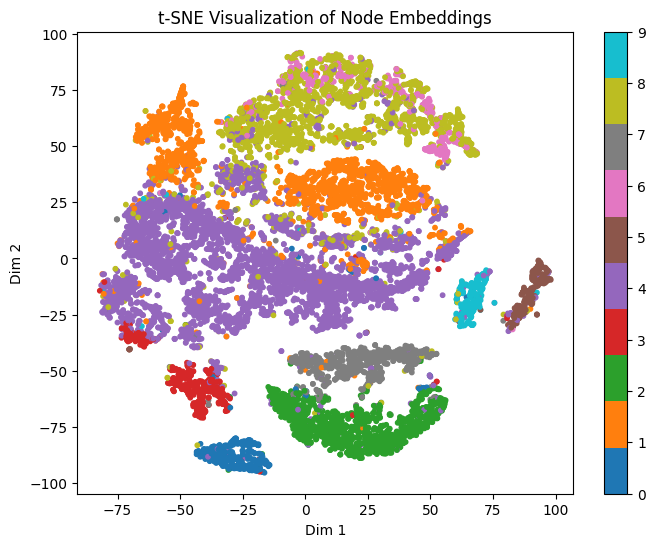

In [73]:
import matplotlib.pyplot as plt

labels = data.y.cpu().numpy()

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=labels,
    cmap='tab10',
    s=10
)

plt.colorbar(scatter)
plt.title("t-SNE Visualization of Node Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.show()

In [74]:
#Highlighting misclassified nodes
with torch.no_grad():
    logits = GAT_model_4(data.x, data.edge_index,return_embedding=False)
    preds = logits.argmax(dim=1).cpu().numpy()

labels = data.y.cpu().numpy()
correct = (preds == labels)

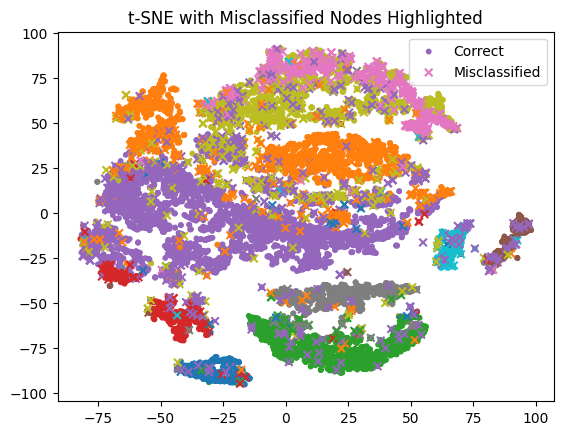

In [75]:
# Correct predictions → circles
plt.scatter(
    emb_2d[correct, 0],
    emb_2d[correct, 1],
    c=labels[correct],
    cmap='tab10',
    s=10,
    marker='o',
    label='Correct'
)

# Wrong predictions → crosses
plt.scatter(
    emb_2d[~correct, 0],
    emb_2d[~correct, 1],
    c=labels[~correct],
    cmap='tab10',
    s=30,
    marker='x',
    label='Misclassified'
)

plt.legend()
plt.title("t-SNE with Misclassified Nodes Highlighted")
plt.show()